<a href="https://colab.research.google.com/github/navap3206-debug/PROYECTO_LAB/blob/main/CARRERA_CABALLOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **LIBRERIAS**

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
from google.colab import files
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from skopt import BayesSearchCV
from skopt.space import Real
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import FunctionTransformer
from sklearn.neural_network import MLPClassifier
from skopt.space import Integer
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

# ***CARRERA DE CABALLOS***

## Objetivos

### Generales
Analisar el desempeño de tres distintos modelos de clasificación y evaluar su capacidad predictivan para estimar la probabilidad de victoria en carreras de caballos esto mediante las características básicas del deporte como son raza, jinete, entrenador, amnbiente e incluso considerando momios (Pari-Mutuel); priorizando datos pre-ganador.

### Específicos
Ingeniería de Características y Preprocesamiento: Estructurar un pipeline de datos capaz de manejar muchas dimensiones y dispersión, integrando variables categóricas con conjuntos unicos muy grandes como (IDs únicos de jinetes, entrenadores y caballos) mediante técnicas de One-Hot Encoding, y normalizando  la asimetría de los momios (win_odds) mediante transformaciones logarítmicas debido a la naturaleza de su distribución.

Optimización de Hiperparámetros: Implementar técnicas de Búsqueda Bayesiana con validación cruzada (Cross-Validation) para calibrar eficientemente los hiperparametros de tres modelos base: Regresión Logística, Máquina de Vectores de Soporte (SVM) y un Perceptrón Multicapa (MLP).

Gestion de Riesgo Financiero: Sustituir la evaluación con metricos tradicionales tradicional por Precisión Promedio (PR-AUC / Área bajo la curva Precision-Recall) para penalizar estrictamente los falsos positivos, garantizando que el modelo minimice perdidas por entrada y proteja el capital al emitir señales de apuesta.

Análisis de Fronteras de Decisión: Contrastar el rendimiento de modelos lineales (SAGA) contra modelos capaces de manejar interacciones no lineales (Kernel RBF y Deep Learning) para determinar qué enfoque captura mejor la complejidad de los datos deportivos.

## Marco teórico

* Regresión logística:Se utiliza como el modelo base que estima la probabilidad de pertenencia a una clase mediante la función sigmoide, siendo fundamental para entender la influencia directa de variables predictoras (Scikit-learn, s.f.).
* Máquinas de vectores de soporte: Este algoritmo busca el hiperplano que maximice el margen entre las clases de ganadores y perdedores, demostrando robustez frente a datos con múltiples dimensiones (Scikit-learn, s.f.).
* Redes neuronales (Multi-layer perceptron): Es un modelo compuesto por capas de neuronas que, mediante funciones de activación no lineales, permite capturar relaciones complejas y patrones sutiles entre las estadísticas del caballo y su rendimiento final (IBM, s.f.).
* Kernels: Son funciones matemáticas que permiten a modelos como SVM operar en un espacio de mayor dimensión sin necesidad de calcular explícitamente las coordenadas de dicho espacio. Esto facilita la separación de datos que no son linealmente clasificables en su forma original (Scikit-learn, s.f.).
* Métricos para clasificación: Más allá de la exactitud, se analizan métricas como Precisión, Recall y F1-Score, las cuales son fundamentales cuando existe un desequilibrio de clases (Machine Learning Mastery, 2020).
* Hiperparámetros: Son las configuraciones externas al modelo que controlan el proceso de aprendizaje, como la tasa de aprendizaje o la profundidad de los árboles, y que deben definirse antes del entrenamiento (AWS, s.f.).
* Optimización Bayesiana: Es una técnica de ajuste de hiperparámetros que utiliza modelos probabilísticos para encontrar de manera eficiente la mejor configuración del modelo, minimizando el error en menos iteraciones que otros métodos (AWS, s.f.).
* Br-AUC: Dado que ganar una carrera es un evento raro, la métrica PR-AUC resulta superior al ROC-AUC tradicional, ya que mide el equilibrio entre la relevancia de los resultados positivos y la capacidad del modelo para encontrarlos en datos desbalanceados (Machine Learning Mastery, 2020).
* Tema elegido para proyecto: Predicción de victorias en carreras de caballos mediante modelos de clasificación y optimización de hiperparámetros. El enfoque consiste en utilizar datos históricos para identificar ineficiencias en el sistema Pari-Mutuel y maximizar el PR-AUC para detectar ganadores con precisión.
* Pari-Mutuel: Es el sistema de apuestas común en las carreras de caballos donde los apostadores juegan unos contra otros. En este sistema, las cuotas se calculan según el volumen de dinero apostado, representando una "sabiduría de la multitud" que el modelo analítico intenta superar (Britannica, s.f.).

# Análisis de dataset (Horse Racing)










* ¿De dónde viene?

  Los datos provienen de diversas fuentes públicas y registros oficiales de las carreras de pura sangre en Hong Kong (históricamente recopilados del Hong Kong Jockey Club, aunque el autor los consolidó y anonimizó).

* ¿Qué contiene?
  
  El dataset contiene identificadores únicos para la carrera, el caballo, el entrenador y el jinete, resultados como la posición final, si ganó, y distancia en cuerpos con respecto al ganador, algunas apuestas como la probabilidad de victoria y la probabilidad de posición.

  Además tiene una cantidad importante de atributos de los caballos, tales como Edad, país de origen, tipo de caballo, peso declarado, peso real, equipamiento y calificación del rendimiento del caballo.
  

  El dataset también contiene algunas métricas temporales sobre el rendimiento en la carrera, tales como la posición del caballo en el tramo de la carrera, la distancia con el lider en el tramo de la carrera, tiempo final en cruzar la pista.


* ¿Qué información dan las muestras?

  En cada muestra es el comportamiento de un participante frente a ese mercado. Te da variables de entrada (su peso, cajón de salida) y el "precio" que el mercado le asignaba antes de empezar (las cuotas u odds), así como el resultado real (en qué posición terminó)

* ¿Qué se quiere analizar?

  El objetivo es determinar qué factores (como el peso, el carril de salida o el jinete) influyen realmente en que un caballo gane una carrera. Básicamente, se analiza la probabilidad de victoria de cada caballo para identificar quién tiene más opciones de ganar y detectar si existen caballos con mejores posibilidades de las que sugieren las apuestas.

* ¿Qué variables se tienen que transformar para usarse en un modelo de regresión?

  Las variables numéricas se tienen que escalar, las variables categóricas se tienen que transformar usando One-Hot Encoding FALTA LA PARTE DE LA COLUMNA SESGADA

* ¿Qué transformaciones se van a usar?
 1. Codificación (Encoding): Aplicar One-Hot Encoding (variables dummy) para las variables categóricas nominales.

 2. Escalado / Estandarización: Usar herramientas como StandardScaler o MinMaxScaler en variables continuas (distancia, peso, premios).

 3. (Probable) Transformación Logarítmica: Para variables con distribuciones muy sesgadas a la derecha (como los dividendos pagados o los premios), aplicar $\log(x + 1)$ ayuda a normalizar la distribución de los datos.

* ¿Qué resultado se podría encontrar al realizar una regresión?

  La variable objetivo sería binaria (Ganó = 1, Perdió = 0). El resultado del modelo te dará la probabilidad $P(Ganar)$ de cada caballo.

  (Daley, s.f.)

## ***EDA***

In [ ]:
dt = files.upload()

Saving runs.csv to runs.csv


In [ ]:
df = pd.read_csv('runs.csv')

In [ ]:
#ANALISIS DE COLUMNAS DISPONIBLES
df.head()

,race_id,horse_no,horse_id,result,won,lengths_behind,horse_age,horse_country,horse_type,horse_rating,...,time2,time3,time4,time5,time6,finish_time,win_odds,place_odds,trainer_id,jockey_id
0,0,1,3917,10,0.0,8.00,3,AUS,Gelding,60,...,21.59,23.86,24.62,NaN,NaN,83.92,9.7,3.7,118,2
1,0,2,2157,8,0.0,5.75,3,NZ,Gelding,60,...,21.99,23.30,23.70,NaN,NaN,83.56,16.0,4.9,164,57
2,0,3,858,7,0.0,4.75,3,NZ,Gelding,60,...,21.59,23.90,24.22,NaN,NaN,83.40,3.5,1.5,137,18
3,0,4,1853,9,0.0,6.25,3,SAF,Gelding,60,...,21.83,23.70,24.00,NaN,NaN,83.62,39.0,11.0,80,59
4,0,5,2796,6,0.0,3.75,3,GB,Gelding,60,...,21.75,23.22,23.50,NaN,NaN,83.24,50.0,14.0,9,154


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79447 entries, 0 to 79446
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   race_id          79447 non-null  int64  
 1   horse_no         79447 non-null  int64  
 2   horse_id         79447 non-null  int64  
 3   result           79447 non-null  int64  
 4   won              79447 non-null  float64
 5   lengths_behind   79447 non-null  float64
 6   horse_age        79447 non-null  int64  
 7   horse_country    79445 non-null  object 
 8   horse_type       79445 non-null  object 
 9   horse_rating     79447 non-null  int64  
 10  horse_gear       79447 non-null  object 
 11  declared_weight  79447 non-null  float64
 12  actual_weight    79447 non-null  int64  
 13  draw             79447 non-null  int64  
 14  position_sec1    79447 non-null  int64  
 15  position_sec2    79447 non-null  int64  
 16  position_sec3    79447 non-null  int64  
 17  position_sec

In [ ]:
#ANALISIS DE NULLS
print(df.isnull().sum())

race_id                0
horse_no               0
horse_id               0
result                 0
won                    0
lengths_behind         0
horse_age              0
horse_country          2
horse_type             2
horse_rating           0
horse_gear             0
declared_weight        0
actual_weight          0
draw                   0
position_sec1          0
position_sec2          0
position_sec3          0
position_sec4      33221
position_sec5      69368
position_sec6      78151
behind_sec1            0
behind_sec2            0
behind_sec3            0
behind_sec4        33221
behind_sec5        69368
behind_sec6        78151
time1                  0
time2                  0
time3                  0
time4              33221
time5              69368
time6              78151
finish_time            0
win_odds               0
place_odds          3735
trainer_id             0
jockey_id              0
dtype: int64


Existen muchas columnas con nulos significativos, por suerte la mayoría no son de interés para la investigación debido a que son datos que se recopilan durante la carrera como lo son time(n) que representa el tiempo en el sector "n" o la position_sec(n), etc. Solo será nevesario en el caso horse_country y   horse_type   .

In [ ]:
#ELIMINAOS NULLS....
features_to_use = [ 'horse_country', 'horse_type']
df = df.dropna(subset=features_to_use)

In [ ]:
#expulso las columnas inecesarias...
df = df.drop(['race_id','time1', 'time2', 'time3', 'time4', 'time5', 'time6', 'behind_sec1','behind_sec2','behind_sec3','behind_sec4','behind_sec5','behind_sec6','position_sec1','position_sec2','position_sec3','position_sec4','position_sec5','position_sec6', 'place_odds','finish_time'], axis=1)


In [ ]:
df.info() #priporizamos considerar características post-resultados

<class 'pandas.core.frame.DataFrame'>
Index: 79445 entries, 0 to 79446
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   horse_no         79445 non-null  int64  
 1   horse_id         79445 non-null  int64  
 2   result           79445 non-null  int64  
 3   won              79445 non-null  float64
 4   lengths_behind   79445 non-null  float64
 5   horse_age        79445 non-null  int64  
 6   horse_country    79445 non-null  object 
 7   horse_type       79445 non-null  object 
 8   horse_rating     79445 non-null  int64  
 9   horse_gear       79445 non-null  object 
 10  declared_weight  79445 non-null  float64
 11  actual_weight    79445 non-null  int64  
 12  draw             79445 non-null  int64  
 13  win_odds         79445 non-null  float64
 14  trainer_id       79445 non-null  int64  
 15  jockey_id        79445 non-null  int64  
dtypes: float64(4), int64(9), object(3)
memory usage: 10.3+ MB


Analisis de distribución y relaciones:

In [ ]:
columnas_numericas = ['result','won','horse_age', 'horse_rating', 'declared_weight', 'actual_weight', 'win_odds', 'draw','lengths_behind'] #agrgamos result para complementar las relaciones pero no es parte del modelo

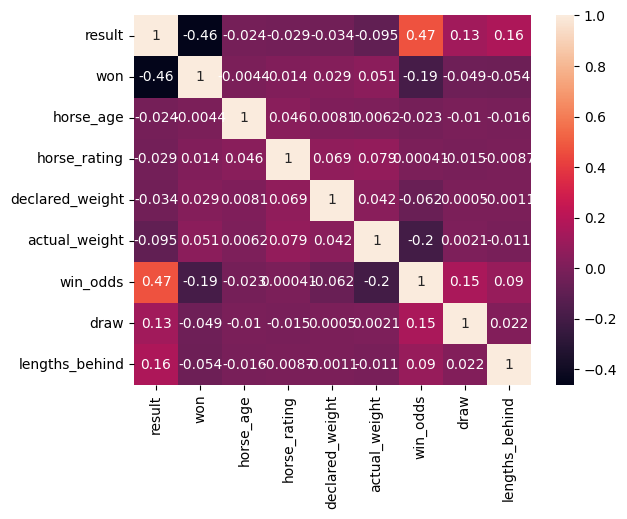

In [ ]:
#heatmap
sns.heatmap(df[columnas_numericas].corr(), annot=True)
plt.show()

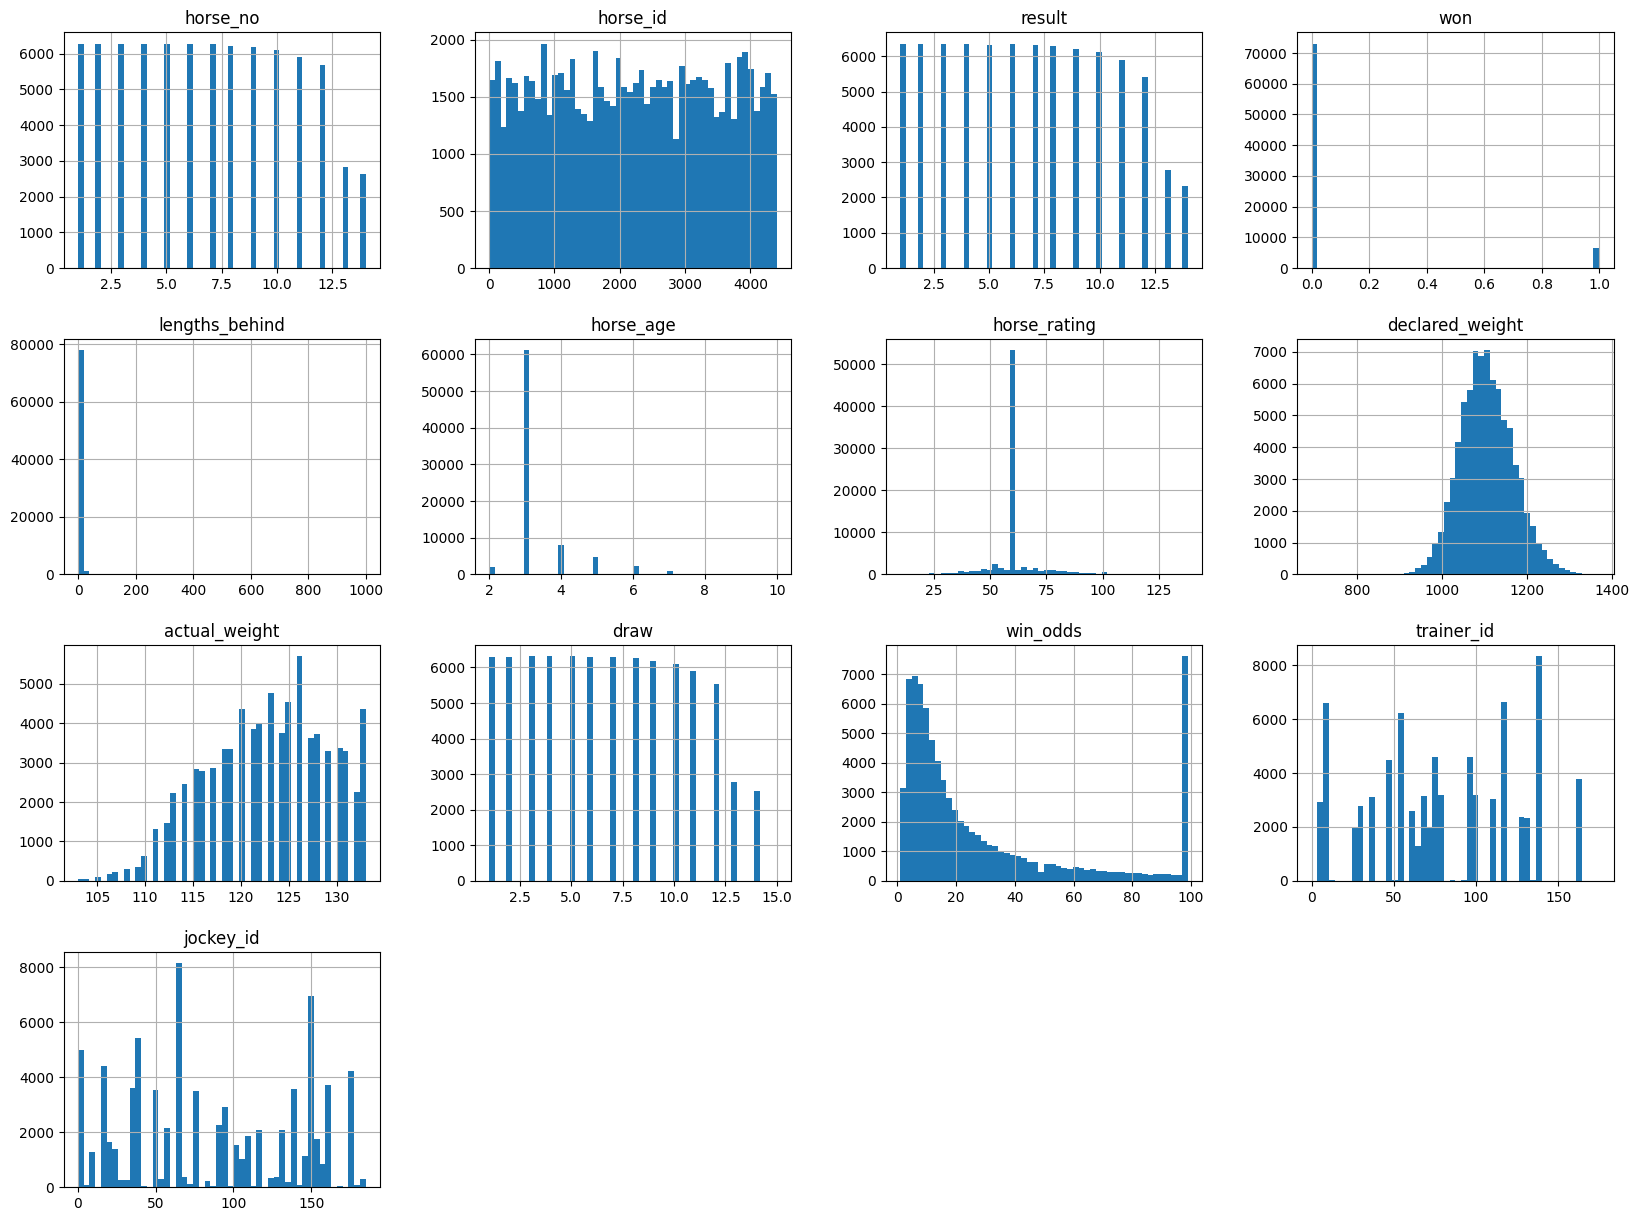

In [ ]:
#Hitogramas
df.hist(bins=50, figsize=(20,15))
plt.show()

## **HALLAZGOS**

* Durante el análisis de la distribución de los momios (win_odds), se identificó un límite de censura artificial en el valor 99.0 acumulando todos los +99, era obvio que la relación de los momios con el resultado de la carrera hiba a tener una relación fuerte sin embargo posee un claro sesgo, y a su vez posee un alta frecuencia en 100 como valor atipico así que tendremos que comprimirla con una transformación logaritmica antes de entrenar los modelos; ya que esto prod´ria distrosionar los moedelos.

* La variable predictora *won*  muestra que los caballos en general pierden lo cual es cierto pero podría generar metricos buenos pero a la vez ficticios ya que el 90% de las veces se pierde y es facil decir que el caballo pierde en general. Al parecer se recomienda aplicarel parámetro class_weight='balanced' en los modelos.


# ***Modelos propuestos*** (cada uno con optimización de hiperparámetros via procesos gaussianos)
* Regresión logística con regularización
* Máquina de vectores de soporte con kernel RBF
* Multi-layer perceptron

## Pipeline (Diagrama incluyendo limpieza de datos, transformaciones de columnas, escalamiento, etc)

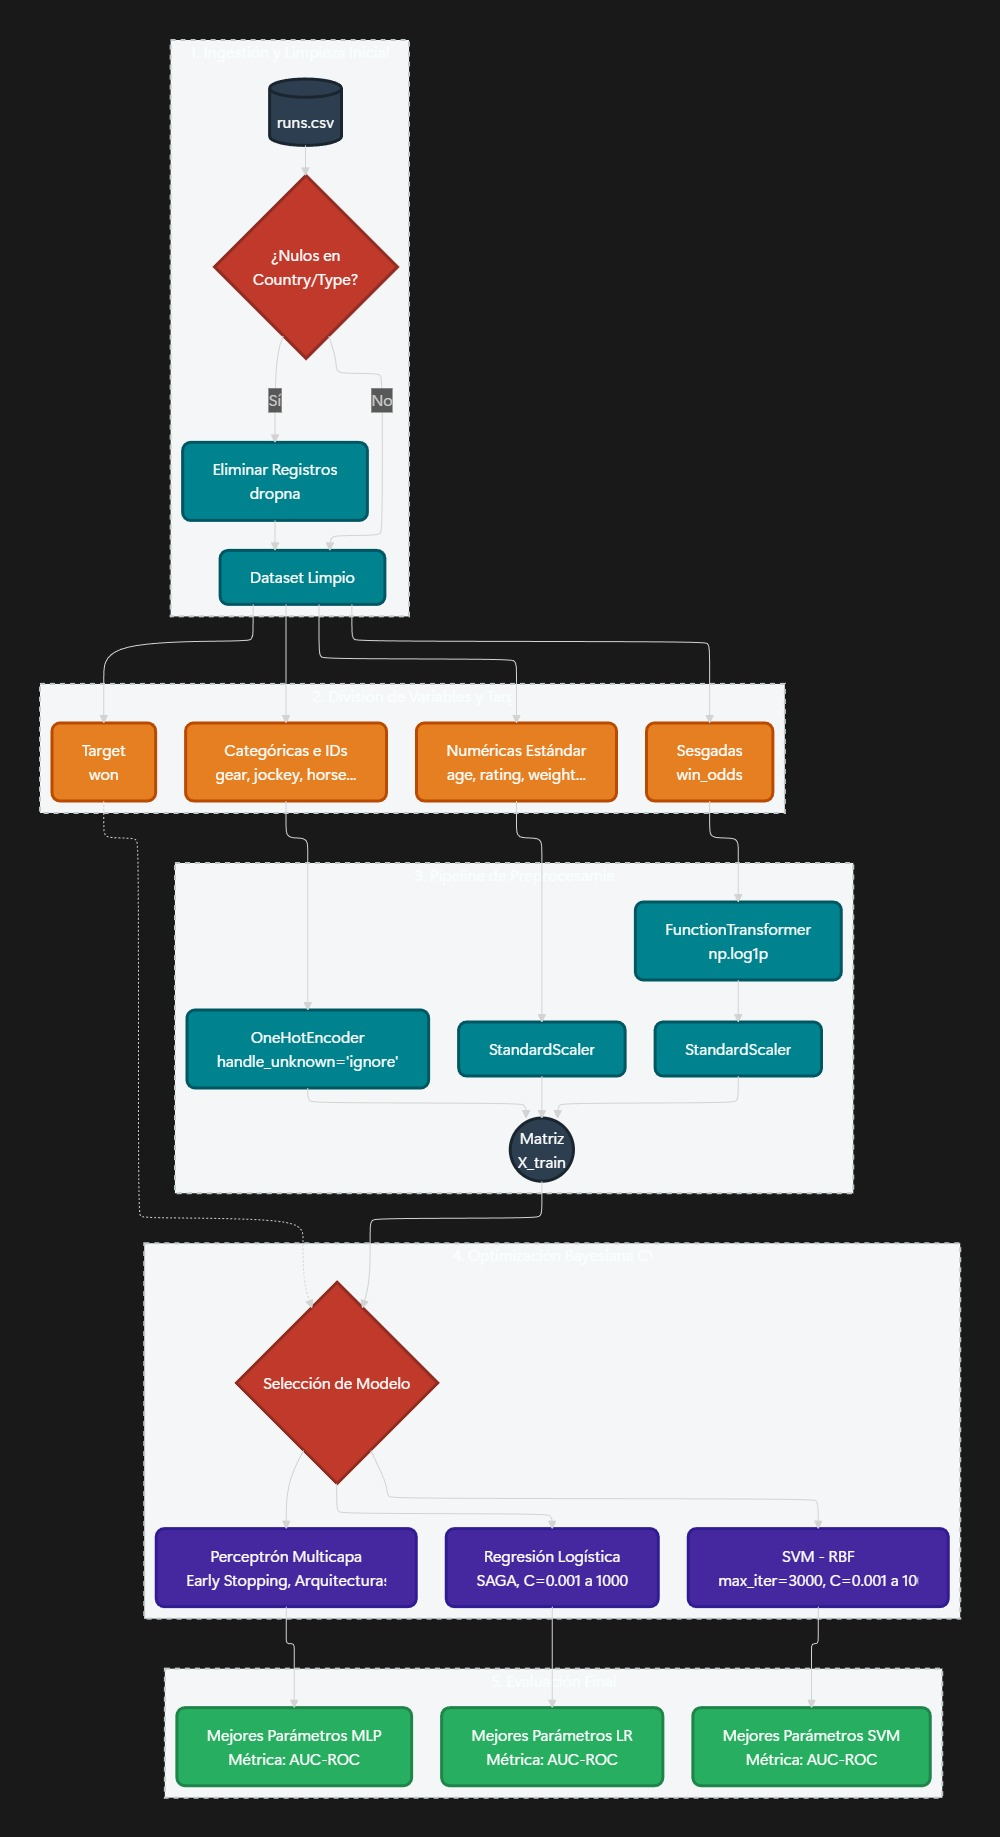

## ***REGRESIÓN LOSGÍSTICA***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79445 entries, 0 to 79446
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   horse_no         79445 non-null  int64  
 1   horse_id         79445 non-null  int64  
 2   result           79445 non-null  int64  
 3   won              79445 non-null  float64
 4   lengths_behind   79445 non-null  float64
 5   horse_age        79445 non-null  int64  
 6   horse_country    79445 non-null  object 
 7   horse_type       79445 non-null  object 
 8   horse_rating     79445 non-null  int64  
 9   horse_gear       79445 non-null  object 
 10  declared_weight  79445 non-null  float64
 11  actual_weight    79445 non-null  int64  
 12  draw             79445 non-null  int64  
 13  win_odds         79445 non-null  float64
 14  trainer_id       79445 non-null  int64  
 15  jockey_id        79445 non-null  int64  
dtypes: float64(4), int64(9), object(3)
memory usage: 10.3+ MB


In [ ]:
numerical_columns = ['horse_age', 'horse_rating', 'declared_weight', 'actual_weight', 'draw']
categorical_columns = ['horse_country', 'horse_type', 'horse_gear', 'trainer_id', 'jockey_id', 'horse_id']
cols_sesgadas = ['win_odds']
target_col = ['won']

In [ ]:
#declaramos nuestrs matrix X Y Aseguramos que los IDs sean strings para el OHE
X = df[cols_sesgadas + numerical_columns + categorical_columns].copy()
for col in ['trainer_id', 'jockey_id', 'horse_id']:
    X[col] = X[col].astype(str)

In [ ]:
y = df[target_col].values.ravel()

In [ ]:
#PIPELINE DE PREPROCESAMIENTO
log_pipeline = Pipeline(steps=[('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),('scaler', StandardScaler())]) #ESTO NOS PERMITIRA COMPRIMIR LOS MOMIOS
escaler = StandardScaler()
categoricos = OneHotEncoder(drop='first', handle_unknown='ignore')    # handle_unknown='ignore' es importante ya que no queremos que explote por la cantidad de jinetas que manejamos


preprocesor = ColumnTransformer(transformers=[
    ('sesgadas', log_pipeline, cols_sesgadas),
    ('num_std', escaler, numerical_columns),
    ('cat', categoricos, categorical_columns)
])



In [ ]:
#MODELOS A IMPLEMENTAR
log_model = LogisticRegression(max_iter=2000, class_weight='balanced', solver='saga', random_state=42) #despúes de pruebas optamos por SAGA debido al manejo de muchos datos y limitamos las iteraciones

In [ ]:
#PIPLINE COMPLETO:
log_pipeline = Pipeline(steps=[('preprocesor', preprocesor), ('model', log_model)])

### optimización bayesiana para el parametro **C**

In [ ]:
param_distributions_lr = {
    'model__C': Real(0.001, 1000, prior='log-uniform')
}

bayes_search_lr = BayesSearchCV(
    estimator=log_pipeline,
    search_spaces=param_distributions_lr,
    n_iter=10,
    cv=4,
    scoring='average_precision',
    random_state=42,
    n_jobs=2 #2 nucleos porque usamos colab
)

bayes_search_lr.fit(X, y)

print(f"MEJOR PARAMETRO: {bayes_search_lr.best_params_}")
print(f"MEJOR SCORE: {bayes_search_lr.best_score_}")

MEJOR PARAMETRO: OrderedDict({'model__C': 0.0010514335809941064})
MEJOR SCORE: 0.2628612752108779


### PORQUE ESTE MÉTRICO: En el supuesto que arriesgar el dinero en una apuesta no segura es peor que simplemente no arrriesgar y además considerando el fuerte sesgo de nuestra variable a predecir se opto por **PR-AUC** A diferencia del ROC, el PR-AUC ignora por completo los Verdaderos Negativos enfoncandonos en las victorias. Evalúa qué tan bien el modelo maximiza los aciertos positivos sin disparar las FALSE. Practicamente trabajo bajo el mismo concepto de area bajo la curva porbando varios umbrales pero priorizando positivos de calidad.

## ***SUPPORT VECTOR MACHINE***

In [ ]:
model_svm = SVC(probability=True, kernel="rbf", class_weight='balanced', max_iter=3000, random_state=42) #RBF debido al tipo de problema

In [ ]:
pipeline_svm = Pipeline(steps=[('preprocesor', preprocesor), ('model', model_svm)])

OPTIMIZACIÓJN BAYESIANA DE C Y GAMMA


CONSIDERANDO:
* Gamma y C altos: Pueden llevar a un modelo que memoriza los datos de entrenamiento (sobreajuste).
* Gamma y C bajos: Pueden llevar a un modelo que no aprende la estructura de los datos (subajuste).

In [ ]:
param_distributions_svm = {
    'model__C': Real(0.001, 1000, prior='log-uniform'),
    'model__gamma': Real(0.001, 0.1, prior='log-uniform')
}

In [ ]:
bayes_search_svm = BayesSearchCV(
    estimator=pipeline_svm,
    search_spaces=param_distributions_svm,
    n_iter=10,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs= 2
)

# Entrenas:
bayes_search_svm.fit(X, y)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


BayesSearchCV(cv=3,
              estimator=Pipeline(steps=[('preprocesor',
                                         ColumnTransformer(transformers=[('sesgadas',
                                                                          Pipeline(steps=[('log',
                                                                                           FunctionTransformer(feature_names_out='one-to-one',
                                                                                                               func=<ufunc 'log1p'>)),
                                                                                          ('scaler',
                                                                                           StandardScaler())]),
                                                                          ['win_odds']),
                                                                         ('num_std',
                                                                          StandardScaler(),
                                                                          ['horse_age',
                                                                           'horse_rating',
                                                                           'declared_weight',
                                                                           'actual_weight',
                                                                           'draw']),
                                                                         ('cat',...
                                                                           'jockey_id',
                                                                           'horse_id'])])),
                                        ('model',
                                         SVC(class_weight='balanced',
                                             max_iter=3000, probability=True,
                                             random_state=42))]),
              n_iter=10, n_jobs=2, random_state=42, scoring='average_precision',
              search_spaces={'model__C': Real(low=0.001, high=1000, prior='log-uniform', transform='normalize'),
                             'model__gamma': Real(low=0.001, high=0.1, prior='log-uniform', transform='normalize')})

In [ ]:
print(f"MEJOR PARAMETRO: {bayes_search_svm.best_params_}")
print(f"MEJOR SCORE: {bayes_search_svm.best_score_}")

MEJOR PARAMETRO: OrderedDict({'model__C': 0.0010514335809941064, 'model__gamma': 0.04321753967138224})
MEJOR SCORE: 0.16439871128426634


##***PERCEPTRON MULTICAPA***

In [ ]:
model_mlp = MLPClassifier(max_iter=2000, early_stopping=True, random_state=42) #early stopping para optmizar el aprendizage
pipeline_mlp = Pipeline(steps=[('preprocesor', preprocesor), ('model', model_mlp)])

### ***OPTIMIZACIÓN BYESSIANA de CAPAS, ALPHA, LEARNING RATE INIT***

* alpha penaliza los pesos grandes, obligando a la red a usar solo las variables que realmente importan y apagando el ruido.
* Leaning Rate int establece tamaño de los "pasos" que da la red mientras aprende, no queremos que aprenda tan rapido ni tan lento.

In [ ]:
param_distributions_mlp = {
    'model__hidden_layer_sizes': Integer(25, 200), # Buscará el tamaño ideal entre 25 y 125 neuronas
    'model__alpha': Real(0.0001, 0.1, prior='log-uniform'),
    'model__learning_rate_init': Real(0.0001, 0.1, prior='log-uniform')
}

In [ ]:
bayes_search_mlp = BayesSearchCV(
    estimator=pipeline_mlp,
    search_spaces=param_distributions_mlp,
    n_iter=15,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs= 2
)

bayes_search_mlp.fit(X,y)

print(f"MEJOR PARAMETRO: {bayes_search_mlp.best_params_}")
print(f"MEJOR SCORE: {bayes_search_mlp.best_score_}")

MEJOR PARAMETRO: OrderedDict({'model__alpha': 0.027364528220782454, 'model__hidden_layer_sizes': 55, 'model__learning_rate_init': 0.006225026900894044})
MEJOR SCORE: 0.24003611540367123


Debido a un bug con las tuplas a la hora de pedirle rastrear entre varias capas, probaremos aparte su rendimeinto con dos capas para buscar una mejora o manetner el enfoque 1 capa:

In [ ]:
model_mlp = MLPClassifier(max_iter=2000,hidden_layer_sizes=(150, 60), early_stopping=True, random_state=42) #early stopping para optmizar el aprendizage

In [ ]:
param_distributions_mlp = {
    'model__alpha': Real(0.0001, 0.1, prior='log-uniform'),
    'model__learning_rate_init': Real(0.0001, 0.1, prior='log-uniform')
}

In [ ]:
bayes_search_mlp = BayesSearchCV(
    estimator=pipeline_mlp,
    search_spaces=param_distributions_mlp,
    n_iter=15,
    cv=3,
    scoring='average_precision',
    random_state=42,
    n_jobs= 2
)

bayes_search_mlp.fit(X,y)

print(f"MEJOR PARAMETRO: {bayes_search_mlp.best_params_}")
print(f"MEJOR SCORE: {bayes_search_mlp.best_score_}")

MEJOR PARAMETRO: OrderedDict({'model__alpha': 0.04638752464241776, 'model__learning_rate_init': 0.00021521979292774904})
MEJOR SCORE: 0.2421705922561629


Si hay un aumento de puntaje pero no es significativo

# ***Conclusión***


### ***RESULTADOS***

ENTRENAMIENTO CON LA POBLACIÓN COMPLETA

In [ ]:
perdedor1 = bayes_search_svm #usamos el mejor parametro automaticamente
perdedor2 = bayes_search_mlp

In [ ]:

y_pred_proba = perdedor1.predict_proba(X)[:, 1]
y_pred_class = perdedor1.predict(X)

roc_auc = roc_auc_score(y, y_pred_proba)
pr_auc = average_precision_score(y, y_pred_proba)


In [ ]:

print(f'roc_auc_svm: {roc_auc}')
print(f'pr_auc_svm: {pr_auc}')


roc_auc_svm: 0.7102362373784639
pr_auc_svm: 0.19082376470352158


In [ ]:
y_pred_proba = perdedor2.predict_proba(X)[:, 1]
y_pred_class = perdedor2.predict(X)

roc_auc = roc_auc_score(y, y_pred_proba)
pr_auc = average_precision_score(y, y_pred_proba)

In [ ]:
print(f'roc_auc_mlp: {roc_auc}')
print(f'pr_auc_mlp: {pr_auc}')

print("--- REPORTE DE SEÑALES ---")
print(classification_report(y, y_pred_class))

tn, fp, fn, tp = confusion_matrix(y, y_pred_class).ravel() #COMPARAMOS CON LA REALIDAD

print("\n--- RESUMEN DE PORTAFOLIO ---")
print(f"Apuestas Ganadas (Victorias Reales):        {tp}")
print(f"Apuestas Perdidas (Drawdown):               {fp}")
print(f"Capital Protegido (Evitaste apostar):      {tn}")
print(f"Oportunidades Perdidas (Ganó y no lo viste): {fn}")

roc_auc_mlp: 0.8002384748008156
pr_auc_mlp: 0.2853618415415524
--- REPORTE DE SEÑALES ---
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     73085
         1.0       0.80      0.00      0.00      6360

    accuracy                           0.92     79445
   macro avg       0.86      0.50      0.48     79445
weighted avg       0.91      0.92      0.88     79445


--- RESUMEN DE PORTAFOLIO ---
Apuestas Ganadas (Victorias Reales):        12
Apuestas Perdidas (Drawdown):               3
Capital Protegido (Evitaste apostar):      73082
Oportunidades Perdidas (Ganó y no lo viste): 6348


In [ ]:
campeon = bayes_search_lr

y_pred_proba = campeon.predict_proba(X)[:, 1]
y_pred_class = campeon.predict(X)


roc_auc = roc_auc_score(y, y_pred_proba)
pr_auc = average_precision_score(y, y_pred_proba)

print(f"ROC-AUC:       {roc_auc:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}\n")

print("--- REPORTE DE SEÑALES ---")
print(classification_report(y, y_pred_class))


tn, fp, fn, tp = confusion_matrix(y, y_pred_class).ravel() #COMPARAMOS CON LA REALIDAD

print("\n--- RESUMEN DE PORTAFOLIO ---")
print(f"Apuestas Ganadas (Victorias Reales):        {tp}")
print(f"Apuestas Perdidas (Drawdown):               {fp}")
print(f"Capital Protegido (Evitaste apostar):      {tn}")
print(f"Oportunidades Perdidas (Ganó y no lo viste): {fn}")

ROC-AUC:       0.7902
PR-AUC:   0.2655

--- REPORTE DE SEÑALES ---
              precision    recall  f1-score   support

         0.0       0.97      0.66      0.78     73085
         1.0       0.16      0.77      0.27      6360

    accuracy                           0.67     79445
   macro avg       0.57      0.71      0.53     79445
weighted avg       0.91      0.67      0.74     79445


--- RESUMEN DE PORTAFOLIO ---
Apuestas Ganadas (Victorias Reales):        4882
Apuestas Perdidas (Drawdown):               24954
Capital Protegido (Evitaste apostar):      48131
Oportunidades Perdidas (Ganó y no lo viste): 1478


In [ ]:
#tipo de momios dentro de la casa de apuestas
print(df['win_odds'].describe())
print(df['win_odds'].mode())
df['win_odds'].hist(bins=1000, figsize=(10,5))
plt.show()


HALlAZGOS:

1. MLP (PR-AUC: 0.2853 / ROC-AUC: 0.80)
Durante el entrenamiento con BayesSearchCV (Cross-Validation) probablekmente al tener menos datos en cada pedazo, la Regresión Logística más simple se veía más estable. Sin embargo, cuando el optimizador terminó y reentrenó el MLP con el 100% de los datos de entrenamiento juntos, la red neuronal profunda tuvo el volumen de información que necesitaba y obtuvo un puntaje imporesionante.

Ese salto de 0.24 a 0.285 en PR-AUC significa que lared neuronal de dos capas  logró encontrar combinaciones no lineales consiguiendo relaciones más complehjas la regresión losgística

2. Regresión Logística (PR-AUC: 0.2655 / ROC-AUC: 0.79)
Mantuvo su número casi idéntico al del entrenamiento (pasó de 0.262 a 0.265). Esto habla de la consistencia, el modelo al parecer no posee  Overfitting . sin embargo con la limitante de su linealidad al buscar relacionesasín que no puede aprender más allá de lo evidente.

3. SVM (PR-AUC: 0.1908)
Después de investigar resulta que La Máquina de Vectores de Soporte se asfixia con las  columnas llenas de ceros debido a nuestros 5000 columnas de ctaegpricos en el ONe hot encoder. Su rendimiento  es pobre comparado con los otros dos modelos, además de que sus tiempos de entrenamientos son un DOLOR DE CABEZA llegando a demorar 1hr 30min.

# **LOGRO**:
COnsiderando que en el registro de carreras analizado el no. de competidores rondan entre 10 a 14 caballos dandonos una probabilidad promedio de 1/12 en atinarle al caballo ganador osea 8.33% aproximadamente, y basandonos en los retornos (win_odd) de la casa de apuestas en HOng Kong, podemos simular un  bankroll donde la esperanza del proceso sea ganancia (IMAGEN) considerando que la moda de los momios es igual a 10. Por lo tanto podemos afirmar que mediante la aplicación de modelos de machine learning se pueden clasificar (ligeramente) características fundamentales de un caballo ganador y por lo tanto conseguir ventaja estadística dentro de las apuestas de caballos. Al menos aplicando modelos losgíticos y de perecpton multicapa.

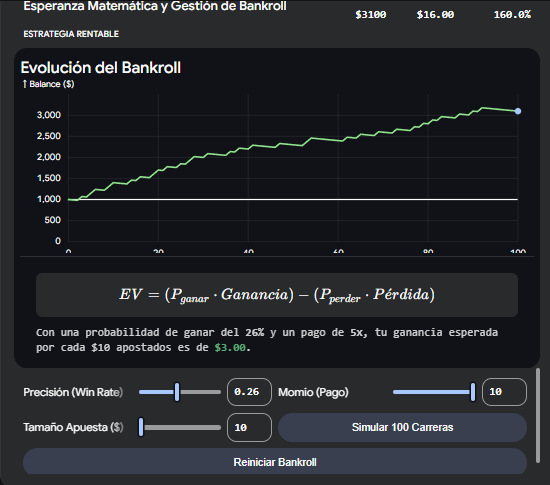

BIBLIOGRAFÍA:

Daley, G. (s.f.). Horse Racing in HK [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/gdaley/hkracing

AWS. (s.f.). ¿Qué es el ajuste de hiperparámetros?. Amazon Web Services. https://aws.amazon.com/es/what-is/hyperparameter-tuning/

Britannica, T. Editors of Encyclopaedia. (s.f.). Pari-mutuel. Encyclopedia Britannica. https://www.britannica.com/topic/pari-mutuel

IBM. (s.f.). What is a multi-layer perceptron?. IBM Topics. https://www.ibm.com/topics/neural-networks

Machine Learning Mastery. (2020). ROC Curves and Precision-Recall Curves for Classification. https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/

Scikit-learn. (s.f.). Logistic Regression. Scikit-learn documentation. https://scikit-learn.org/stable/modules/linear_model.html

Scikit-learn. (s.f.). Support Vector Machines. Scikit-learn documentation. https://scikit-learn.org/stable/modules/svm.html